# T019 ·分子动力学模拟
* * 注意：** 这篇谈话文章是TeachOpenCADD的一部分，该平台旨在教授特定领域的技能并提供管道模板作为研究项目的起点。

作者：
- Pietro Gerletti，2020年CADD研讨会，Charité/FU柏林
- Mareike Leja，2020/21，在[Amsteramer Lab，Charité]实习（https：//volkamerab.org/）
- Jeffrey R Wagner，2020年，[Open Force Field Consortium](https：//openforcefield.org/）
- David Scholer，2020/21，[Amplamer Lab，Charité]（https：//volkamerab.org/）
- Andrea Thomamer，2020/21，[Thomamer Lab，Charité]（https：//volkamerab.org/)

## 本期脱口秀的目标

在本期谈话中，我们将了解为什么分子动力学（MD）模拟对于药物设计很重要，以及对与配体复合的蛋白质进行MD模拟所需的步骤。受体受体将作为模拟的样本系统。

# * 理论 * 内容
- 分子动力学
- 力场
- 边界条件
- MD模拟和药物设计
- EGFR激酶

# 参考资料
- 回顾MD模拟在药物发现中的影响([_J Med Chem_(2016)，**59**(9)，4035‐4061](https://doi.org/10.1021/acs.jmedchem.5b01684))
- 回顾MD模拟和最佳实践背后的物理原理([_Living J Comp Mol Sci_(2019)，**1**(1)，5957](https://doi.org/10.33011/livecoms.1.1.5957))
- 力场回顾([_J化学信息模型_(2018)，**58**(3)，565-578](https://doi.org/10.1021/acs.jcim.8b00042))
- 癌症中的表皮生长因子受体综述([_癌症(巴塞尔)_(2017)，**9**(5)，52](https://dx.doi.org/10.3390%2Fcancers9050052))
- 皮埃尔-西蒙·拉普拉斯总结的统计知识(概率分析S戈蒂尔-维拉尔斯)，**3**)](https://archive.org/details/uvrescompltesde31fragoog/page/n15/mode/2up)
- 灵感来自Jaime Rodriguez-Guera([github](https://github.com/jaimergp/uab-msc-bioinf/blob/master/MD%20Simulation%20and%20Analysis%20in%20a%20Notebook.ipynb))的笔记本电脑形式
- [OpenMM](https://github.com/openmm/openmm)和[OpenMM Forcefields](https://github.com/openmm/openmmforcefields)，[RDKit](https://github.com/rdkit/rdkit)，[PyPDB](https://github.com/williamgilpin/pypdb)，[MDTraj](https://github.com/mdtraj/mdtraj)，[PDBFixer](https://github.com/openmm/pdbfixer))的存储库
- 维基百科关于[MD simulations](https://en.wikipedia.org/wiki/Molecular_dynamics)，[琥珀](https://en.wikipedia.org/wiki/AMBER)和[Force fields](https://en.wikipedia.org/wiki/Force_field_(chemistry))])的文章

## 理论

# 分子动力学

In [1]:
import sys

on_colab = "google.colab" in sys.modules
if on_colab:
    %pip install teachopencadd --no-deps -q
    !teachopencadd -d 19
    %pip uninstall teachopencadd -y -q
    %pip install -qr requirements.txt
    %conda install mdtraj openmm openmmforcefields openff-toolkit pdbfixer pypdb rdkit -y -c conda-forge

分子动力学是一种分析确定系统中原子和分子的运动和相互作用的计算方法。该方法源于理论物理学，它是在20世纪50年代发展起来的(阿尔德和温赖特在[_J Chem Phys_(1959)，**31**(2)，459]中(https://doi.org/10.1063/1.1730376))，)，尽管它背后的想法可以追溯到更早的时间：

一种能够在任何时刻理解一切使自然生机勃勃的力量和构成它的生物的各自位置的智慧，而且，如果这种智慧足够深远，足以对这些数据进行分析，那么它将在这个公式中既包括宇宙中最大物体的运动，也包括最轻原子的运动：对它来说，没有什么是不确定的，未来和过去都将呈现在它的眼前。人类的头脑为我们提供了这种智慧的一个模糊的轮廓，就像它赋予天文学的那样完美。(皮埃尔-西蒙·拉普拉斯，1820)


让我们把拉普拉斯的这一说法作为分子动力学模拟的思想基础。换句话说，我们可以通过了解其组件的特性并应用牛顿运动定律来近似物理系统的行为。通过求解运动方程，我们可以得到系统的分子轨迹，它是一系列关于其所有粒子的位置和速度以及势能的快照。要做到这一点，我们定义了称为力场的函数，它提供了对系统中每个粒子施加的所有力的近似描述。然后利用数值积分器求解系统的初值问题，得到系统的运动轨迹。听起来，这个过程需要相当多的处理能力，直到几年前，MD才开始看到更广泛的使用，特别是在计算化学和生物学领域，以及在药物发现中([_J Med Chem_(2016)，**59**(9)，4035‐4061](https://doi.org/10.1021/acs.jmedchem.5b01684)).

! [MD_rotor_250K_1ns.gif](https：//github.com/volkamerlab/teachopencadd/raw/d1ded86bb2c82ef088cc5145d0bcb997f6eab7dd/teachopencadd/talktorials/018_md_simulation/images/MD_rotor_250K_1ns.gif）
* * 图1**：由三个分子组成的超分子在受限纳米孔中旋转的分子动力学模拟（Palma等人，通过[维基媒体]（commons.wikimedia.org/w/index.php? curid=34866205)。

# 强制场



力场描述了分子内部原子之间以及分子之间的作用力。它们是带有不同力(键拉伸、范德瓦尔斯等)分量的参数方程。参数值通常是通过实验得出的，根据所涉及的分子和模拟设置的不同，这些参数值对于每个MD场景都是不同的。结果是对系统能量格局的数学描述，其中作用在每个粒子上的力是由势能相对于原子坐标的梯度产生的。

有几个力场可用，每个力场都有自己的特征([_J化学信息模型_(2018)，**58**(3)，565-578](https://doi.org/10.1021/acs.jcim.8b00042)).在这本笔记本中，我们将使用琥珀力场家族的一个成员，该家族被广泛用于蛋白质的MD模拟。它们的功能形式是：

$$V(r^N)=\sum_{i\in ond}k_{bi}(L_i-L^0_i)^2+\sum_{i\in角度}k_{ai}(\theta_i-\theta^0_i)^2+\sum_{i\in torsion}\sum_n\frac{1}{2}V_i^n[1+cos(NW_i-\Gamma_i)]$$
$$+\sum_{j=1}^{N-1}\sum_{i=j+1}^{N}f_{ij}\in ij[(\frac{r^0_{ij}}{r_{ij}})^{12}-2(\frac{r^0_{ij}}{r_{ij}})^{6}]+\frac{q_iq_j}{4\pi\in_0 r_{ij}}$$

该公式由不同成分的总和组成。前三个分量包含有关键长、角度和扭转（分子内力）的信息。最后一个组成部分描述了分子间的非键力，例如范德华力和静电相互作用。各种参数（用星号0表示）取决于所使用的磁场，并且在AMBER磁场家族的所有成员之间有所不同。请注意，这些电场假设固定电荷粒子，不允许极化，也不考虑局部电荷如何影响其周围环境。 

下面的电场组件视觉表示以更直观的方式展示了相同的概念。

! [MM_PEF.png](https：//github.com/volkamerlab/teachopencadd/raw/d1ded86bb2c82ef088cc5145d0bcb997f6eab7dd/teachopencadd/talktorials/018_md_simulation/images/MM_PEF.png）
* * 图2**：分子力学力场的组成部分（Edboas通过[维基媒体]（commons.wikimedia.org/w/index.php? curid=4194424）)。

# 边界条件

通常，分子系统是在充满水等溶剂的盒子中模拟的。这些盒子的尺寸有限，这导致盒子边界处或附近的分子出现问题。这些分子应该与哪些分子相互作用？周期性边界条件可以通过模拟理论上无限系统来避免此类边界伪影。从而，盒子一个边界的分子与盒子另一侧边界的分子相互作用。这模拟了模拟框被其自身复制品包围的情况。当可视化此类MD模拟时，人们经常可以观察到粒子从一侧离开盒子（图3）。然而，它们以相同的速度同时重新出现在盒子的另一边。对于周期性边界条件下的模拟，建议使用足够大的模拟框，以便模拟的大分子不会与其自身的邻近图像接触。

! [MD_water.gif](https：//github.com/volkamerlab/teachopencadd/raw/d1ded86bb2c82ef088cc5145d0bcb997f6eab7dd/teachopencadd/talktorials/018_md_simulation/images/MD_water.gif）
* * 图3**：具有周期性边界条件的水分子的分子动力学模拟（Kmckiern通过[维基媒体]（https：//commons.wikimedia.org/wiki/Fileb：MD_water.gif）)。

# MD模拟与药物设计

分子动力学模拟对配体与靶结合的高度动态过程提供了有价值的见解。当配体(或药物)接近溶液中的大分子(蛋白质)时，它会遇到一个不断运动的结构。此外，配体可以诱导大分子中最能适应小分子的构象变化。这种构象可能无法用静态方法发现。因此，在静态无配体结构中没有观察到但可以通过MD模拟发现的结合位点有时被称为*隐蔽结合位点*([_J Med Chem_(2016)，**59**(9)，4035‐4061](https://doi.org/10.1021/acs.jmedchem.5b01684)).用分子动力学模拟识别这种结合位点可以启动新药发现活动。在药物发现过程的后期，在进行成本更高、时间更密集的体外试验之前，MD模拟也可以用来估计通过计算机识别的小分子的质量。总之，MD模拟在计算机药物设计中是一项宝贵的资产。

# EGFR激酶

表皮生长因子受体(EGFR)是一种重要的药物靶点，与癌症和炎症([Wikipedia](https://en.wikipedia.org/wiki/Epidermal_growth_factor_receptor)).有关。它是一种跨膜蛋白，具有细胞外受体结构域和细胞内激酶域。内源性配体表皮生长因子的结合通过二聚化和自磷酸化导致激活域的激活。然后，激活的激酶结构域可以磷酸化下游的信号蛋白，触发DNA合成和细胞增殖([癌症(巴塞尔)_(2017)，**9**(5)，52](https://dx.doi.org/10.3390%2Fcancers9050052)).抑制该激酶是几种已获批准的抗癌药物([DrugBank](https://go.drugbank.com/bio_entities/BE0000767)).的潜在作用机制在本说明书中，我们使用该激酶的PDB结构**3POZ**，它与小分子抑制剂**03P**形成复合体，进行MD模拟([PDB：3POZ](https://www.rcsb.org/structure/3poz)).

! [3poz_assembly-1.jpeg](https：//github.com/volkamerlab/teachopencadd/raw/ed3b2b6b655589d71355295af4c89363a63558b9/teachopencadd/talktorials/018_md_simulation/images/3poz_assembly-1.jpeg）
* * 图4**：与抑制剂03 P结合的表皮生长因子（[DBC：3 POZ]（https：//www.rcsb.org/structure/3poz）)。

## 实用

我们现在将继续使用分子动力学引擎[OpenMM](https：//github.com/openmm/openmm)执行MD模拟，这是一个用于分子模拟的高性能工具包。它是开源的，可以用作应用程序或库。我们将把它用作Python库。

# 导入依赖项

# 下载DBC文件
蛋白质数据库（[DBC](https：//www.rcsb.org/）)允许通过URL轻松下载文件。

# 准备蛋白质配体复合物

In [2]:
import copy
from pathlib import Path

import requests
from IPython.display import display
import numpy as np
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import AllChem
import mdtraj as md
import pdbfixer
import openmm as mm
import openmm.app as app
from openmm import unit
from openff.toolkit.topology import Molecule, Topology
from openmmforcefields.generators import GAFFTemplateGenerator


In [3]:
#如果不存在，则创建数据目录
HERE = Path(_dh[-1])
DATA = HERE / "data"
DATA.mkdir(exist_ok=True)


# 蛋白质制备

成功模拟的关键部分是一个正确且完整的系统。从蛋白质数据库检索到的晶体结构经常遗漏原子，主要是氢，并且可能包含非标准残基。在本期谈话中，我们将使用Python包[PDBFixer](https：//github.com/openmm/pdbfixer）来准备蛋白质结构。然而，[PDBFixer]（https：//github.com/openmm/pdbfixer)不能很好地处理共结晶的配体，因此将单独制备。

In [4]:
pdbid = "3POZ"
ligand_name = "03P"
pdb_path = DATA / f"{pdbid}.pdb"
pdb_url = f"https://files.rcsb.org/download/{pdbid}.pdb"


In [5]:
r = requests.get(pdb_url)
r.raise_for_status()
with open(pdb_path, "wb") as f:
    f.write(r.content)


# 准备配体

准备好蛋白质后，我们将注意力转向配体。同样，我们需要添加氢原子，但还需要确保键阶被正确分配，因为一些DBC条目可能包含错误。我们使用Python包[RDKit](https：//github.com/rdkit/rdKit），这是一个开源化学信息学库。
我们将通过SMILES字符串向[RDKit]（https：//github.com/rdkit/rdKit）提供正确的质子化状态和键阶。每个共结晶配体的不带电同分SMILES串可以在其各自的[TSB]（https：//www.example.com）条目中找到。www.rcsb.org DBC条目[3POZ]（https：//www.rcsb.org/structure/3poz）的配体名称为[03P]（https：//www.rcsb.org/ligand/03P)。如果配体可能以其带电形式或特定互变体结合，则需要将此类特征融入SMILES串中。

In [6]:
def prepare_protein(
    pdb_file, ignore_missing_residues=True, ignore_terminal_missing_residues=True, ph=7.0
):
    """
    Use pdbfixer to prepare the protein from a PDB file. Hetero atoms such as ligands are
    removed and non-standard residues replaced. Missing atoms to existing residues are added.
    Missing residues are ignored by default, but can be included.

    Parameters
    ----------
    pdb_file: pathlib.Path or str
        PDB file containing the system to simulate.
    ignore_missing_residues: bool, optional
        If missing residues should be ignored or built.
    ignore_terminal_missing_residues: bool, optional
        If missing residues at the beginning and the end of a chain should be ignored or built.
    ph: float, optional
        pH value used to determine protonation state of residues

    Returns
    -------
    fixer: pdbfixer.pdbfixer.PDBFixer
        Prepared protein system.
    """
    fixer = pdbfixer.PDBFixer(str(pdb_file))
    fixer.removeHeterogens()  # co-crystallized ligands are unknown to PDBFixer
    fixer.findMissingResidues()  # identify missing residues, needed for identification of missing atoms

    #如果应忽略缺失的末端残基，请将其从字典中删除
    if ignore_terminal_missing_residues:
        chains = list(fixer.topology.chains())
        keys = fixer.missingResidues.keys()
        for key in list(keys):
            chain = chains[key[0]]
            if key[1] == 0 or key[1] == len(list(chain.residues())):
                del fixer.missingResidues[key]

    #如果所有缺失的残基都应被忽略忽略，则清除字典
    if ignore_missing_residues:
        fixer.missingResidues = {}

    fixer.findNonstandardResidues()  # find non-standard residue
    fixer.replaceNonstandardResidues()  # replace non-standard residues with standard one
    fixer.findMissingAtoms()  # find missing heavy atoms
    fixer.addMissingAtoms()  # add missing atoms and residues
    fixer.addMissingHydrogens(ph)  # add missing hydrogens
    return fixer


In [7]:
#准备蛋白质并仅构建缺失的非末端残基
prepared_protein = prepare_protein(pdb_path, ignore_missing_residues=False)


使用从[03P]的DBC条目中获取的同质SMILES字符串调用此函数（https：//www.rcsb.org/ligand/03P）将返回正确准备的配体。打印的是原始配体和准备好的配体的2D表示，以供检查。

# 合并蛋白质和配体

在下一步中，我们希望使用Python包[MDTraj](https：//github.com/mdtraj/mdtraj）合并准备的蛋白质和配体结构。[MDTraj]（https：//github.com/mdtraj/mdtraj）可以处理制备的蛋白质，该蛋白质目前是[PDBFixer]（https：//github.com/openmm/pdbfixer）分子，一种具有类似于[OpenMM Modeller]（http：//docs.openmm.org/latest/userguide/application.html#model-building-and-editing）的结构和位置。然而，对于配体，我们需要进行多次转换，因为它目前是[RDKit]（https：//github.com/rdkit/rdKit)分子。

In [8]:
def prepare_ligand(pdb_file, resname, smiles, depict=True):
    """
    Prepare a ligand from a PDB file via adding hydrogens and assigning bond orders. A depiction
    of the ligand before and after preparation is rendered in 2D to allow an inspection of the
    results. Huge thanks to @j-wags for the suggestion.

    Parameters
    ----------
    pdb_file: pathlib.PosixPath
       PDB file containing the ligand of interest.
    resname: str
        Three character residue name of the ligand.
    smiles : str
        SMILES string of the ligand informing about correct protonation and bond orders.
    depict: bool, optional
        show a 2D representation of the ligand

    Returns
    -------
    prepared_ligand: rdkit.Chem.rdchem.Mol
        Prepared ligand.
    """
    #分裂分子
    rdkit_mol = Chem.MolFromPDBFile(str(pdb_file))
    rdkit_mol_split = Chem.rdmolops.SplitMolByPDBResidues(rdkit_mol)

    #提取配体并去除任何已经存在的氢
    ligand = rdkit_mol_split[resname]
    ligand = Chem.RemoveHs(ligand)

    #从模板分配保证单
    reference_mol = Chem.MolFromSmiles(smiles)
    prepared_ligand = AllChem.AssignBondOrdersFromTemplate(reference_mol, ligand)
    prepared_ligand.AddConformer(ligand.GetConformer(0))

    #质子配体
    prepared_ligand = Chem.rdmolops.AddHs(prepared_ligand, addCoords=True)
    prepared_ligand = Chem.MolFromMolBlock(Chem.MolToMolBlock(prepared_ligand))

    # 2D描绘
    if depict:
        ligand_2d = copy.deepcopy(ligand)
        prepared_ligand_2d = copy.deepcopy(prepared_ligand)
        AllChem.Compute2DCoords(ligand_2d)
        AllChem.Compute2DCoords(prepared_ligand_2d)
        display(
            Draw.MolsToGridImage(
                [ligand_2d, prepared_ligand_2d], molsPerRow=2, legends=["original", "prepared"]
            )
        )

    #返回配体
    return prepared_ligand


现在蛋白质和配体都采用[OpenMM](https：//github.com/openmm/openmm）类似的格式，并且可以与[MDTraj]（https：//github.com/mdtraj/mdtraj)合并。

[10:10:57] WARNING: More than one matching pattern found - picking one



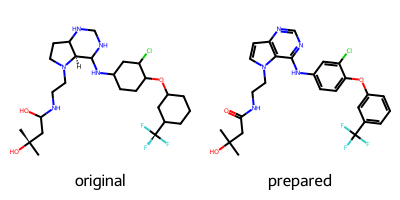

In [9]:
smiles = "CC(C)(O)CC(=O)NCCn1ccc2ncnc(Nc3ccc(Oc4cccc(c4)C(F)(F)F)c(Cl)c3)c12"
rdkit_ligand = prepare_ligand(pdb_path, ligand_name, smiles)


# MD模拟设置

我们现在可以使用准备好的综合体来设置MD模拟。 

In [10]:
def rdkit_to_openmm(rdkit_mol, name="LIG"):
    """
    Convert an RDKit molecule to an OpenMM molecule.
    Inspired by @hannahbrucemcdonald and @glass-w.

    Parameters
    ----------
    rdkit_mol: rdkit.Chem.rdchem.Mol
        RDKit molecule to convert.
    name: str
        Molecule name.

    Returns
    -------
    omm_molecule: openmm.app.Modeller
        OpenMM modeller object holding the molecule of interest.
    """
    #将RDKit转换为OpenFF
    off_mol = Molecule.from_rdkit(rdkit_mol)

    #添加分子名称
    off_mol.name = name

    #添加原子的名称
    element_counter_dict = {}
    for off_atom, rdkit_atom in zip(off_mol.atoms, rdkit_mol.GetAtoms()):
        element = rdkit_atom.GetSymbol()
        if element in element_counter_dict.keys():
            element_counter_dict[element] += 1
        else:
            element_counter_dict[element] = 1
        off_atom.name = element + str(element_counter_dict[element])

    #从OpenFF转换为OpenMM
    off_mol_topology = off_mol.to_topology()
    mol_topology = off_mol_topology.to_openmm()
    mol_positions = off_mol.conformers[0]

    #将单位从ngström转换为纳米
    #因为OpenMM在纳米中工作
    mol_positions = mol_positions.to("nanometers")

    #结合建模器对象中的布局和位置
    omm_mol = app.Modeller(mol_topology, mol_positions)

    return omm_mol


In [11]:
omm_ligand = rdkit_to_openmm(rdkit_ligand, ligand_name)


# 磁场

ABER等常见的磁场具有氨基酸、核酸、水和离子的参数，通常根据您的目标提供多种选择。我们使用' amber 14-all. html ' force字段文件，该文件随OpenMM一起提供，包括蛋白质、DNA、RNA和脂质的参数。对于溶剂化，我们使用标准的三点[水模型](https：//en.wikipedia.org/wiki/Water_models）[** TIP 3 P **]（https：//aip.scitation.org/doi/10.1063/1.445869）。

然而，不包括配体的参数。为了生成这些参数，我们可以使用 **G** general **A** MBE *F**orce** F* F *ield（[GAFF]（http：//ambermd.org/antechamber/gaff.html）），它在Python包[OpenMM Forcefields]（https：//github.com/openmm/openmmforcefields)中实现。以下函数生成一个包含标准ABER参数的电场对象，并在需要时还包括小分子的参数。

In [12]:
def merge_protein_and_ligand(protein, ligand):
    """
    Merge two OpenMM objects.

    Parameters
    ----------
    protein: pdbfixer.pdbfixer.PDBFixer
        Protein to merge.
    ligand: openmm.app.Modeller
        Ligand to merge.

    Returns
    -------
    complex_topology: openmm.app.topology.Topology
        The merged topology.
    complex_positions: openmm.unit.quantity.Quantity
        The merged positions.
    """
    #结合topics
    md_protein_topology = md.Topology.from_openmm(protein.topology)  # using mdtraj for protein top
    md_ligand_topology = md.Topology.from_openmm(ligand.topology)  # using mdtraj for ligand top
    md_complex_topology = md_protein_topology.join(md_ligand_topology)  # add them together
    complex_topology = md_complex_topology.to_openmm()

    #组合位置
    total_atoms = len(protein.positions) + len(ligand.positions)

    #创建一个数组，用于将所有原子位置存储为包含值和单位的塔佩尔
    #称为OpenMM收件箱
    complex_positions = unit.Quantity(np.zeros([total_atoms, 3]), unit=unit.nanometers)
    complex_positions[: len(protein.positions)] = protein.positions  # add protein positions
    complex_positions[len(protein.positions) :] = ligand.positions  # add ligand positions

    return complex_topology, complex_positions


In [13]:
complex_topology, complex_positions = merge_protein_and_ligand(prepared_protein, omm_ligand)


/home/michael/.teachopencadd_envs/teachopencadd_T019_py312/lib/python3.12/site-packages/openmm/unit/quantity.py:750: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  self._value[key] = value / self.unit


In [14]:
print("Complex topology has", complex_topology.getNumAtoms(), "atoms.")
#NBVAR_RST_输出


Complex topology has 5561 atoms.


# 系统

通过我们配置的电场，我们现在可以使用[OpenMM Modeller](http：//docs.openmm.org/latest/userguide/application.html#model-building-and-editing)类来创建MD环境，这是一个包含复合体并充满溶剂的模拟框。标准溶剂是含有指定量离子的水。盒子的大小可以通过各种方式确定。我们用填充来定义它，这会产生一个立方体盒子，其维度取决于复合体的最大维度。

> 请注意，此步骤可能需要很长时间，大约几分钟，具体取决于您的硬件。

In [15]:
def generate_forcefield(
    rdkit_mol=None, protein_ff="amber14-all.xml", solvent_ff="amber14/tip3pfb.xml"
):
    """
    Generate an OpenMM Forcefield object and register a small molecule.

    Parameters
    ----------
    rdkit_mol: rdkit.Chem.rdchem.Mol
        Small molecule to register in the force field.
    protein_ff: string
        Name of the force field.
    solvent_ff: string
        Name of the solvent force field.

    Returns
    -------
    forcefield: openmm.app.Forcefield
        Forcefield with registered small molecule.
    """
    forcefield = app.ForceField(protein_ff, solvent_ff)

    if rdkit_mol is not None:
        gaff = GAFFTemplateGenerator(
            molecules=Molecule.from_rdkit(rdkit_mol, allow_undefined_stereo=True)
        )
        forcefield.registerTemplateGenerator(gaff.generator)

    return forcefield


In [16]:
forcefield = generate_forcefield(rdkit_ligand)


通过我们的溶剂化系统和力场，我们最终可以创建一个[OpenMM系统](http：//docs.openmm.org/development/api-python/generated/openmm.openmm.System.html#openmm.openmm.System）并设置模拟。
除了系统之外，模拟还需要一个集成商。[OpenMM Integrator]（http：//docs.openmm.org/development/api-python/library.html#Integrators）定义了一种通过积分运动方程来模拟系统的方法。选择的 **Langevin积分器 ** 使用Langevin方程。所有不同类型集成商的列表可以在[OpenMM收件箱]（http：//docs.openmm.org/development/api-python/library.html#Integrators）中找到。要进一步了解 **Langevin积分器 **，我们建议阅读有关Langevin方程的信息，例如在[维基百科]（https：//en.wikipedia.org/wiki/Langevin_equation)上。

# 执行MD模拟
现在一切都设置好了，我们就可以执行模拟了。我们需要设置启动位置并最小化系统的能量以获得低能量启动配置，这对于减少因严重原子冲突而导致模拟失败的机会非常重要。节省了能源最小化系统。

In [17]:
modeller = app.Modeller(complex_topology, complex_positions)
modeller.addSolvent(forcefield, padding=1.0 * unit.nanometers, ionicStrength=0.15 * unit.molar)


完成最小化后，我们可以执行MD模拟。在这篇脱口秀中，我们将进行一个简短的模拟来说明。出于研究目的的模拟跨越几微秒，甚至高达微秒。我们将仅模拟100 ps的分子动力学，对应于每个2 fs的50 k步。我们每10 ps（5000步）保存一次分子“快照”，总共保存10帧。结果保存在. xtt文件中，其中包含给定时间点所有原子的坐标。与之前编写的能量最小化系统的DBC文件一起，它为我们提供了稍后分析所需的所有信息。 
* * 注意 **：如果不是在Google Colab上，此谈话节目只会生成20 fs轨迹。不过，如果您有一个好的图形处理器可用，您也可以增加模拟时间。

In [18]:
system = forcefield.createSystem(modeller.topology, nonbondedMethod=app.PME)
integrator = mm.LangevinIntegrator(
    300 * unit.kelvin, 1.0 / unit.picoseconds, 2.0 * unit.femtoseconds
)
simulation = app.Simulation(modeller.topology, system, integrator)
simulation.context.setPositions(modeller.positions)


系统中所有粒子的速度都是从给定温度下的分布中随机选择的。我们选择了300开尔文，比室温高出几度。
会生成随机种子，但可以显式地给出该种子来重现结果。

然后通过采取之前定义的步骤来执行模拟。

In [19]:
simulation.minimizeEnergy()
with open(DATA / "topology.pdb", "w") as pdb_file:
    app.PDBFile.writeFile(
        simulation.topology,
        simulation.context.getState(getPositions=True, enforcePeriodicBox=True).getPositions(),
        file=pdb_file,
        keepIds=True,
    )


## 讨论

我们已经成功地进行了蛋白质配体复合体的分子动力学模拟。然而，我们只模拟了相当短的时间，以保持谈话指南的执行时间较短。为了解决药物设计中的关键问题，往往需要更长的模拟时间。
MD模拟的计算成本仍然太高，不能用于这一目的。因此，发展了所谓的增强采样方法，其目的是加速构象采样。一些最常见的方法将在下面的**进一步阅读**部分中讨论。
此外，我们没有包括平衡步骤，该步骤通常用于在开始模拟之前从0到300K缓慢加热系统，并且在模拟包括脂质双层在内的更敏感的系统时可能很重要。由于蛋白质残基的质子化状态和配基的质子化状态是相互影响的，所以分别进行配基和蛋白质的质子化是次优的。然而，我们没有找到一个满足所有需求的免费和开源解决方案。我们非常欢迎您的建议！
如果您想了解如何可视化和分析轨迹，可以参考此库中的**TalktureT020**。

In [20]:
#输出设置
if on_colab:
    steps = 50000  # corresponds to 100 ps
    write_interval = 5000  # write every 10 ps
    log_interval = 2500  # log progress to stdout every 5 ps
else:
    steps = 10  # corresponds to 20 fs
    write_interval = 1  # write every 2 fs
    log_interval = 1  # log progress to stdout every 2 fs
simulation.reporters.append(
    md.reporters.XTCReporter(file=str(DATA / "trajectory.xtc"), reportInterval=write_interval)
)
simulation.reporters.append(
    app.StateDataReporter(
        sys.stdout,
        log_interval,
        step=True,
        potentialEnergy=True,
        temperature=True,
        progress=True,
        remainingTime=True,
        speed=True,
        totalSteps=steps,
        separator="\t",
    )
)


## 测验
* 琥珀色磁场中考虑了哪些分子间和分子内的力？你能想到有什么力量没有考虑在内吗？
* 当使用相同参数运行笔记本电脑两次时，您是否希望看到完全相同的模拟结果？
* 尝试对没有配体的蛋白质进行简短（10 ps，每1 ps快照一次）模拟。您可以在[DBC](https：//www.rcsb.org/)上找到多种结构，或者您可以使用EGFR同工酶并去除配体。

In [21]:
simulation.context.setVelocitiesToTemperature(300 * unit.kelvin)
simulation.step(steps)  # perform the simulation


#"Progress (%)"	"Step"	"Potential Energy (kJ/mole)"	"Temperature (K)"	"Speed (ns/day)"	"Time Remaining"
10.0%	1	-911672.8833984158	300.58994432283663	0	--
20.0%	2	-898806.4210639504	267.2506776332451	1.78	0:00
30.0%	3	-883111.4814176012	238.60290950665717	1.73	0:00
40.0%	4	-867596.4630740668	196.76725273444427	1.68	0:00
50.0%	5	-862553.2471993582	175.87229216182052	1.6	0:00
60.0%	6	-854763.8296435549	163.39398429953755	1.54	0:00
70.0%	7	-852074.9736099411	147.9384677561452	1.5	0:00
80.0%	8	-855085.7518770137	152.24611569256365	1.5	0:00
90.0%	9	-856760.1494785415	157.91401106119835	1.49	0:00
100.0%	10	-861616.5007841537	165.39716192526913	1.49	0:00


In [22]:
#检查轨迹存在且不为空
(DATA / "trajectory.xtc").stat().st_size > 0
#NBVAR_RST_输出


True

## 进一步阅读

In [23]:
if on_colab:
    files.download(DATA / "topology.pdb")
    files.download(DATA / "trajectory.xtc")


# 增强采样方式

从理论上讲，无偏MD模拟应该能够模拟药物分子及其大分子靶标的结合和解离事件。然而，结合和解除结合事件的时间尺度在毫秒到秒的范围内。增强的采样方法旨在加快构象采样([_J Med Chem._2016，**59(9)**，4035-61](https://doi.org/10.1021/acs.jmedchem.5b01684)).

其中之一是**自由能微扰(FEP)**(也称为炼金术自由能计算)，它计算从一种状态A到另一种状态B时的自由能差。它经常被用于铅优化中，以评估配体上的微小修饰，这可能会提高目标的结合亲和力。由此，通过模拟几个中间(炼金术)状态([alchemistry](http://www.alchemistry.org/wiki/Main_Page)).，来自状态A的配体逐渐转变为状态B的配体

另一种计算自由能的技术是**伞采样(美国)**。美国通过使用能量偏差执行阶段性模拟来执行沿着集体变量(CV)的采样。这种偏置通常以谐和电势的形式出现，因此有了“保护伞”一词。它的目标是对CV沿线的高能区域进行采样。然而，由于计算成本较高，限制了其在药物设计中的应用。

相比之下，**转向MD(SMD)**采用了一种不同的方法：它向系统施加外力。这些作用力是时间依赖的，有助于配体从靶标上解离。SMD计算施加在系统上的最终力。然后，解结力分布可以用来过滤来自对接计算的点击，并区分活性和非活性分子。

## Quiz

* Which inter- and intramolecular forces are being considered in the AMBER force field? Can you think of any forces not taken into account?
* Would you expect to see the exact same simulation results when running the notebook twice with the same parameters?
* Try doing a short (10ps, snapshot every 1ps) simulation of a protein without a ligand. You can find a broad variety of structures on [PDB](https://www.rcsb.org/) or you can use the EGFR kinase and remove the ligand.

## Further reading

### Enhanced sampling methods

In theory, unbiased MD simulations should be capable of simulating binding and unbinding events of a drug molecule and its macromolecular target. However, the timescale of binding and unbinding events lies in the millisecond to second range. Enhanced sampling methods aim to accelerate the conformational sampling ([_J Med Chem._ 2016, **59(9)**, 4035-61](https://doi.org/10.1021/acs.jmedchem.5b01684)).

One of these is **Free energy perturbation (FEP)** (also called alchemical free energy calculation), which computes the free energy difference when going from a state A to another state B. It is often employed in lead optimization to evaluate small modification at the ligand, that may boost the binding affinity for the desired target. The ligand from state A is thereby gradually transformed into the ligand of state B by simulating several intermediate ("alchemical") states ([alchemistry](http://www.alchemistry.org/wiki/Main_Page)). 

Another technique for free-energy calculations is **Umbrella sampling (US)**. US enforces sampling along a collective variable (CV) by performing staged simulations with an energetic bias. The bias usually takes the form of a harmonic potential, hence the term "umbrella". Its goal is to sample high-energy regions along the CV. However, the use in drug design is limited by the high computational cost.

In contrast, **Steered MD (SMD)** follows a different approach: it applies external forces to the system. Those forces are time-dependent and facilitate the unbinding of the ligand from the target. The SMD calculates the final force exerted on the system. The unbinding force profile can then be used to filter hits from docking calculations and to discriminate active from inactive molecules.